In [3]:
import sys, os
import torch
import json
from pathlib import Path
from transformers import AutoTokenizer

# hydra imports; not really required if you will hard-code model params in future
from hydra import compose, initialize_config_dir
from hydra.utils import instantiate

# set GENALM_HOME environment variable to point to GENA_LM repo root; required to process config files
GENA_HOME = "/disk/10tb/home/fishman/DNALM/GENA_LM"
os.environ["GENALM_HOME"] = GENA_HOME
sys.path.append(GENA_HOME)

# import model
from downstream_tasks.expression_prediction.expression_model_final import ExpressionCounts
from downstream_tasks.expression_prediction.expression_dataset_final import ExpressionDataset

In [4]:
# we have model parameters and other variables in config files; I made one for inference
experiment_config = "../inference_example/inference.yaml"

experiment_config_path = Path(experiment_config).expanduser().absolute()

with initialize_config_dir(str(experiment_config_path.parents[0])):
	experiment_config = compose(config_name=experiment_config_path.name)

model_kwargs = instantiate(experiment_config["model_kwargs"])

# initialize model
model = ExpressionCounts(**model_kwargs)

/tmp/ipykernel_1320643/2737365626.py:6: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  with initialize_config_dir(str(experiment_config_path.parents[0])):


Using ModernBERT from /disk/10tb/home/fishman/DNALM/GENA_LM/models/modernbert_large/


loading configuration file /disk/10tb/home/fishman/DNALM/GENA_LM/models/modernbert_large/config.json
Model config ModernBertConfig {
  "architectures": [
    "ModernBertForMaskedLM"
  ],
  "attention_bias": false,
  "attention_dropout": 0.0,
  "bos_token_id": 50281,
  "classifier_activation": "silu",
  "classifier_bias": false,
  "classifier_dropout": 0.0,
  "classifier_pooling": "mean",
  "cls_token_id": 1,
  "decoder_bias": true,
  "deterministic_flash_attn": false,
  "embedding_dropout": 0.0,
  "eos_token_id": 50282,
  "global_attn_every_n_layers": 3,
  "global_rope_theta": 10000.0,
  "gradient_checkpointing": false,
  "hidden_activation": "gelu",
  "hidden_size": 1024,
  "initializer_cutoff_factor": 2.0,
  "initializer_range": 0.02,
  "intermediate_size": 2624,
  "layer_norm_eps": 1e-05,
  "local_attention": 128,
  "local_rope_theta": 10000.0,
  "max_position_embeddings": 1024,
  "mlp_bias": false,
  "mlp_dropout": 0.0,
  "model_type": "modernbert",
  "norm_bias": false,
  "norm_ep

missing: 0 []
unexpected: 3 ['decoder.bias', 'head.dense.weight', 'head.norm.weight']
mismatched: []


loading configuration file config.json from cache at /disk/10tb/home/fishman/.cache/huggingface/hub/models--Qwen--Qwen3-Embedding-0.6B/snapshots/c54f2e6e80b2d7b7de06f51cec4959f6b3e03418/config.json
Model config Qwen3Config {
  "architectures": [
    "Qwen3ForCausalLM"
  ],
  "attention_bias": false,
  "attention_dropout": 0.0,
  "bos_token_id": 151643,
  "eos_token_id": 151643,
  "head_dim": 128,
  "hidden_act": "silu",
  "hidden_size": 1024,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_types": [
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_atte

[desc_model] unfrozen transformer blocks: [24, 25, 26, 27] (total blocks=28)
[desc_model] backbone.norm trainable: True (trainable params=1,024)
[desc_model] trainable params: 62,924,800 / 595,776,512
[desc_model] trainable tensors: 45
  - layers.24.self_attn.q_proj.weight
  - layers.24.self_attn.k_proj.weight
  - layers.24.self_attn.v_proj.weight
  - layers.24.self_attn.o_proj.weight
  - layers.24.self_attn.q_norm.weight
  - layers.24.self_attn.k_norm.weight
  - layers.24.mlp.gate_proj.weight
  - layers.24.mlp.up_proj.weight
  - layers.24.mlp.down_proj.weight
  - layers.24.input_layernorm.weight
  - layers.24.post_attention_layernorm.weight
  - layers.25.self_attn.q_proj.weight
  - layers.25.self_attn.k_proj.weight
  - layers.25.self_attn.v_proj.weight
  - layers.25.self_attn.o_proj.weight
  - layers.25.self_attn.q_norm.weight
  - layers.25.self_attn.k_norm.weight
  - layers.25.mlp.gate_proj.weight
  - layers.25.mlp.up_proj.weight
  - layers.25.mlp.down_proj.weight
  - layers.25.input

In [5]:
# load checkpoint
checkpoint_path = os.path.join(GENA_HOME, "models/full_model/pytorch_model.bin")
model.load_state_dict(torch.load(checkpoint_path, map_location="cpu", weights_only=True))

<All keys matched successfully>

In [27]:
# load sequences of 4 genes: HBB, ALB, Sox2, Nanog

expected_genes = ["HBB","ALB", "Sox2", "Nanog"]
with open("data/sequences.fa") as f:
	lines= f.readlines()
gene_names = list(map(lambda x: x[1:].strip(), lines[::2])) # format: >gene_name --> gene_name
sequences = list(map(lambda x: x.strip().upper(), lines[1::2]))
assert all([n1==n2 for n1,n2 in zip(gene_names, expected_genes)])
assert all(set(s)-set("ACGT")==set() for s in sequences)
genes = {gene_name: sequence for gene_name, sequence in zip(gene_names, sequences)}
genes["HBB"] = str.translate(genes["HBB"], str.maketrans("ACGT", "TGCA"))[::-1] # reverse complement HBB, it is on the negative strand

TSS = {"HBB":	"TGGAGCCACACCCTAGGGTTGGCCAATCTACTCCCAGGAGCAGGGAGGGCAGGAGCCAGGGCTGGGCATAAAAGTCAGGGCAGAGCCATCTATTGCTTACATTTGCTTCTGACACAACTGTGTTCACTAGCAACCTCAAACAGACACCATGGTGCATCTGACTCCTGAGGAGAAGTCTGCCGTTACTGCCCTGTGGGGCAAGGTGAACGT", 
	   "ALB":"TGCTAATTTCCCTCCGTTTGTCCTAGCTTTTCTCTTCTGTC",
	   "Sox2": "GATGGTTGTCTATTAACTT",
	   "Nanog": "TTATAAATCTAGAGACTCCAGGATTTTAACG",
	   }
# center around TSS
radius = 9*511 # average token length is 8-9, we add a bit of seq; 511 is half of the max input length
for gene in genes:
	TSS_pos = genes[gene].find(TSS[gene])
	assert TSS_pos != -1
	assert TSS_pos > radius and len(genes[gene])-TSS_pos > radius, \
	 	f"TSS is too close to the edges for {gene}" # check that TSS is not too close to the edges
	center = TSS_pos + len(TSS[gene])//2
	genes[gene] = genes[gene][center-radius:center+radius]

In [28]:
genes

{'HBB': 'GTTTTGATCACAACATTTTGAATTGACTGGCAGCAGAAGCTCTTTTATATCCATGTGTTTTCCTTAAGTCATTATACATAGTAGGCACTGAGAACTCTTTATATCTGAATAAGATATTTAGGAACCACTGGTTTACATATCAGAAGCAGAGCTACTCAGGGCATTTTGGGGAAGATCACTTTCACATTCCTGAGCATAGGGAAGTTCTCATAAGAGTAAGATATTAAAAGGAGATACTTGTGTGGTATTCGAAAGACAGTAAGAGAGATTGTAGACCTTATGATCTTGATAGGGAAAACAAACTACATTCCTTTCTCCAAAAGTCAAAAAAAAAGAGCAAATATAGCTTACTATACCTTCTATTCCTACACCATTAGAAGTAGTCAGTGAGTCTAGGCAAGATGTTGGCCCTAAAAATCCAAATACCAGAGAATTCATGAGAACATCACCTGGATGGGACATGTGCCGAGCACACACAATTACTATATGCTAGGCATTGCTATCTTCATATTGAAGATGAGGAGGTCAAGAGATGAAAAAAGACTTGGCACCTTGTTGTTATATTAAAATTATTTGTTAGAGTAGAGCTTTTGTAAGAGTCTAGGAGTGTGGGAGCTAAATGATGATACACATGGACACAAAAAATAGATCAACAGACACCCAGGCCTACTTGAGGGTTGAGGGTGGGAAGAGGGAGACGATGAAAAAGAACCTATTGGGTATTAAGTTCATCACTGAGTGATGAAATAATCTGTACATCAAGACCCAGTGATATGCAATTTACCTATATAACTTGTACATGTACCCCCAAATTTAAAATGAAAGTTAAAACAAAGTATAGGAATGGAATTAATTCCTCAAGATTTGGCTTTAATTTTATTTGATAATTTATCAAATGGTTGTTTTTCTTTTCTCACTATGGCGTTGCTTTATAAACTATGTTCAGTATGTCTGAATGAAAGGGTGTGTGTGTGTGTGAAAGAGAGGGAGA

In [29]:
# load experiment description: expression in three cell lines, 
# K562 (blood cancer cells), HepG2 (liver cancer cells) and H1 (human embryonic stem cells)

experiments = {"K562": "ENCFF578UUD", "HepG2": "ENCFF588KDY", "H1": "ENCFF081FQX"}
for experiment in experiments:
	description_id = experiments[experiment]
	full_metadata_path = os.path.join("data/", f"{description_id}.json")
	with open(full_metadata_path, "r", encoding="utf-8") as f:
		meta = json.load(f)
	desc = ExpressionDataset.make_description_from_json(meta, description_id, full_metadata_path)
	experiments[experiment] = desc
experiments

{'K562': 'assay term name is polyA plus RNA-seq. description is PolyA RNA-Seq from oligo-dT primed Total RNA on the K562 cell line. biosample summary is Homo sapiens K562. life stage age is adult 53 years. perturbed is False. strand specificity is unstranded. genome annotation is V29. mapped run type is paired-ended. id is ENCFF578UUD. genome is GRCh38.',
 'HepG2': 'assay term name is polyA plus RNA-seq. description is RNA-seq on human HepG2 (paired-ended). biosample summary is Homo sapiens HepG2. life stage age is child 15 years. perturbed is False. strand specificity is forward. genome annotation is V29. mapped run type is single-ended. id is ENCFF588KDY. genome is GRCh38.',
 'H1': 'assay term name is polyA plus RNA-seq. description is The libraries contained in this experiment come from the whole cell fraction of independent growths of the human embryonic stem cell line H1-hESC. They are stranded PE76 Illumina GAIIx RNA-Seq libraries from rRNA-depleted Poly-A+ RNA > 200 nucleotides 

In [38]:
experiments = {
	"K562": "K562 cells that are studied using stranded  RNA-seq. The continuous cell line K-562 was established from the pleural effusion of a 53-year-old female with chronic myelogenous leukemia in terminal blast crises",
	"HepG2": "HepG2 cells which were subjected to transcriptomic assay using Illumina technology",
	"H1": "embryonic stem cell line H1-hESC profiled with PE76 Illumina GAIIx RNA-Seq libraries from rRNA-depleted Poly-A+"
}
experiments

{'K562': 'K562 cells that are studied using stranded  RNA-seq. The continuous cell line K-562 was established from the pleural effusion of a 53-year-old female with chronic myelogenous leukemia in terminal blast crises',
 'HepG2': 'HepG2 cells which were subjected to transcriptomic assay using Illumina technology',
 'H1': 'embryonic stem cell line H1-hESC profiled with PE76 Illumina GAIIx RNA-Seq libraries from rRNA-depleted Poly-A+'}

In [39]:
# prepare tokenizers
dna_tokenizer = experiment_config["args_params"]["gen_tokenizer"]
text_tokenizer = experiment_config["shared_dataset_params"]["text_tokenizer"]
dna_tokenizer = AutoTokenizer.from_pretrained(dna_tokenizer)
text_tokenizer = AutoTokenizer.from_pretrained(text_tokenizer, padding_side='left')

dna_max_seq_len = experiment_config["args_params"]["input_seq_len"]
text_max_seq_len = experiment_config["shared_dataset_params"]["text_max_seq_len"]

loading file tokenizer.json from cache at /disk/10tb/home/fishman/.cache/huggingface/hub/models--AIRI-Institute--gena-lm-bert-base-t2t/snapshots/4f1352bd4e820f1dba341047f54ad7795e083bf2/tokenizer.json
loading file tokenizer.model from cache at None
loading file added_tokens.json from cache at None
loading file special_tokens_map.json from cache at /disk/10tb/home/fishman/.cache/huggingface/hub/models--AIRI-Institute--gena-lm-bert-base-t2t/snapshots/4f1352bd4e820f1dba341047f54ad7795e083bf2/special_tokens_map.json
loading file tokenizer_config.json from cache at /disk/10tb/home/fishman/.cache/huggingface/hub/models--AIRI-Institute--gena-lm-bert-base-t2t/snapshots/4f1352bd4e820f1dba341047f54ad7795e083bf2/tokenizer_config.json
loading file chat_template.jinja from cache at None
loading file vocab.json from cache at /disk/10tb/home/fishman/.cache/huggingface/hub/models--Qwen--Qwen3-Embedding-0.6B/snapshots/c54f2e6e80b2d7b7de06f51cec4959f6b3e03418/vocab.json
loading file merges.txt from cach

In [40]:
# tokenize DNA sequences

tokenized_DNA = dna_tokenizer(
	[genes[i] for i in genes],
	truncation=True,
	padding="max_length",
	max_length=dna_max_seq_len,
	return_tensors="pt",
)
print ("Input IDs shape:", tokenized_DNA["input_ids"].shape)
tokenized_DNA


Input IDs shape: torch.Size([4, 1024])


{'input_ids': tensor([[    1,     9,   113,  ...,   916,  3206,     2],
        [    1,   125,   902,  ..., 17407,  1575,     2],
        [    1,  8407,  1827,  ...,   102,  1566,     2],
        [    1,   647,  1191,  ...,  2728,   163,     2]]), 'token_type_ids': tensor([[0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1]])}

In [41]:
# tokenize experiment description

tokenized_descriptions = {}

for experiment in experiments:
	print ("experiment", experiments[experiment])
	tokenized_descriptions[experiment] = text_tokenizer(
		[experiments[experiment]]*len(genes), # repeat description for each gene
		truncation=True,
		padding="max_length",
		max_length=text_max_seq_len,
		return_tensors="pt",
)

print ("Input IDs shape:", tokenized_descriptions["K562"]["input_ids"].shape)

print ("K562")
print (tokenized_descriptions["K562"])
print ("HepG2")
print (tokenized_descriptions["HepG2"])


experiment K562 cells that are studied using stranded  RNA-seq. The continuous cell line K-562 was established from the pleural effusion of a 53-year-old female with chronic myelogenous leukemia in terminal blast crises
experiment HepG2 cells which were subjected to transcriptomic assay using Illumina technology
experiment embryonic stem cell line H1-hESC profiled with PE76 Illumina GAIIx RNA-Seq libraries from rRNA-depleted Poly-A+
Input IDs shape: torch.Size([4, 510])
K562
{'input_ids': tensor([[151643, 151643, 151643,  ...,  20671,  57087, 151643],
        [151643, 151643, 151643,  ...,  20671,  57087, 151643],
        [151643, 151643, 151643,  ...,  20671,  57087, 151643],
        [151643, 151643, 151643,  ...,  20671,  57087, 151643]]), 'attention_mask': tensor([[0, 0, 0,  ..., 1, 1, 1],
        [0, 0, 0,  ..., 1, 1, 1],
        [0, 0, 0,  ..., 1, 1, 1],
        [0, 0, 0,  ..., 1, 1, 1]])}
HepG2
{'input_ids': tensor([[151643, 151643, 151643,  ...,   2210,   5440, 151643],
        

In [42]:
# side-note: we use last token embedding from text part as "integral" of description
# note that last token is 'end-of-sequence', which is the same token as padding applied to the left
print (tokenized_descriptions["K562"]["input_ids"].shape)
print (tokenized_descriptions["K562"]["input_ids"][0,-1].item())
# this is last token in the text part
print (text_tokenizer.decode(tokenized_descriptions["K562"]["input_ids"][0,-1]))
# this is the first token, which is just pad for our short description
print (text_tokenizer.decode(tokenized_descriptions["K562"]["input_ids"][0,0]))

torch.Size([4, 510])
151643
<|endoftext|>
<|endoftext|>


In [43]:
# cast inputs and run forward pass
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# in out example batch is 4 sequnces with one cell type (experiment description) each
# we have 'macro' batch (N) of 1
# then B=4, N=1, L=len(DNA tokens), D=len(text tokens)

input_ids = tokenized_DNA["input_ids"].to(device) # (B*N, L)
attention_mask = tokenized_DNA["attention_mask"].to(device) # (B*N, L)

# we use dummy labels and labels_mask as we don't need them for inference
labels_mask = torch.ones_like(input_ids, device=device, dtype=torch.bool).unsqueeze(-1).to(device) # (B*N, L, 1)
labels = torch.ones_like(input_ids, device=device, dtype=torch.float32).unsqueeze(-1).to(device) # (B*N, L, 1)

model = model.eval()
model.to(device)

outputs = {}

for experiment in experiments:
	# we add extra dim for N=1
	print ("---> experiment", experiment)
	desc_input_ids = torch.unsqueeze(tokenized_descriptions[experiment]["input_ids"], dim=1).to(device)  # (B, N, D)
	print ("desc_input_ids.shape", desc_input_ids.shape)

	desc_attention_mask = torch.unsqueeze(tokenized_descriptions[experiment]["attention_mask"], dim=0).to(device) # (B, N, D)

	dataset_flag = torch.zeros(size=(input_ids.shape[0], 1), device=device, dtype=torch.bool) # (B, N): 1 -> repeating DNA; 0 -> repeating DESC; we repeat DESC here
	print ("dataset_flag.shape", dataset_flag.shape)
	
	with torch.autocast(device_type="cuda", dtype=torch.bfloat16), torch.no_grad():
			output = model(input_ids=input_ids, attention_mask=attention_mask, desc_input_ids=desc_input_ids, desc_attention_mask=desc_attention_mask, dataset_flag=dataset_flag)

	outputs[experiment] = output

# def forward(
# 	self,
# 	input_ids=None,              # (B*N, L)
# 	attention_mask=None,         # (B*N, L) or None
# 	labels_mask=None,            # (B*N, L, 1)
# 	labels=None,                 # (B*N, L, 1)
# 	return_dict=None,
# 	desc_input_ids=None,           # (B, N, D)
# 	desc_attention_mask = None,
# 	dataset_flag=None,           # (B, N): 1 -> дубли INPUTS; 0 -> дубли DESC
# ):

---> experiment K562
desc_input_ids.shape torch.Size([4, 1, 510])
dataset_flag.shape torch.Size([4, 1])
---> experiment HepG2
desc_input_ids.shape torch.Size([4, 1, 510])
dataset_flag.shape torch.Size([4, 1])
---> experiment H1
desc_input_ids.shape torch.Size([4, 1, 510])
dataset_flag.shape torch.Size([4, 1])


In [44]:
# let's have a look at the output
output = outputs["K562"]

print ("Output shape:", output["logits"].shape)

# token outputs for sample (chunk) 0:
# we use 1:-1 to exclude CLS and SEP tokens
sample_id = 0
print ("Token outputs shape for one sample(experiment):", output["logits"][sample_id,1:-1,:].shape)

# per-sequnce (expression) output:
print ("Expression output shape for one sample(experiment):", output["logits"][sample_id,0,:].shape)

Output shape: torch.Size([4, 1024, 1])
Token outputs shape for one sample(experiment): torch.Size([1022, 1])
Expression output shape for one sample(experiment): torch.Size([1])


Experiment: K562, Gene: HBB, Predicted: 4.84375
Experiment: K562, Gene: ALB, Predicted: 0.337890625
Experiment: K562, Gene: Sox2, Predicted: 0.1669921875
Experiment: K562, Gene: Nanog, Predicted: 0.1259765625
Experiment: HepG2, Gene: HBB, Predicted: 0.306640625
Experiment: HepG2, Gene: ALB, Predicted: 4.15625
Experiment: HepG2, Gene: Sox2, Predicted: 0.13671875
Experiment: HepG2, Gene: Nanog, Predicted: 0.1533203125
Experiment: H1, Gene: HBB, Predicted: 0.33984375
Experiment: H1, Gene: ALB, Predicted: 0.42578125
Experiment: H1, Gene: Sox2, Predicted: 3.140625
Experiment: H1, Gene: Nanog, Predicted: 0.5859375
   Cell Type   Gene  Expression
0       K562    HBB    4.843750
1       K562    ALB    0.337891
2       K562   Sox2    0.166992
3       K562  Nanog    0.125977
4      HepG2    HBB    0.306641
5      HepG2    ALB    4.156250
6      HepG2   Sox2    0.136719
7      HepG2  Nanog    0.153320
8         H1    HBB    0.339844
9         H1    ALB    0.425781
10        H1   Sox2    3.140625


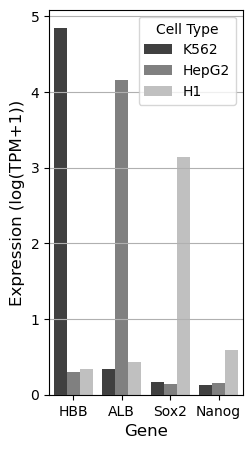

In [45]:
# So, is our model worth something actually?
# ALB (full name is albumin) is one of the most well known hepatocyte-specific markers expressed in liver cells
# HBB is a gene encoding the beta-globin protein, which is a component of hemoglobin in red blood cells
# Let's see if our model can predict expression of these genes correctly

_cell_types = []
_genes = []
_expressions = []

for experiment_name in experiments:
	for gene_id,gene_name in enumerate(genes):
		predicted_expression = outputs[experiment_name]["logits"][gene_id,0,0] # get output from CLS for specific gene
		print (f"Experiment: {experiment_name}, Gene: {gene_name}, Predicted: {predicted_expression}")
		_cell_types.append(experiment_name)
		_genes.append(gene_name)
		_expressions.append(predicted_expression.item())

# Create a DataFrame
import pandas as pd

df = pd.DataFrame({
    'Cell Type': _cell_types,
    'Gene': _genes,
    'Expression': _expressions
})
print (df)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(2.5, 5))
sns.barplot(x='Gene', y='Expression', hue='Cell Type', data=df, palette='gray')
plt.xlabel('Gene', fontsize=12)
plt.ylabel('Expression (log(TPM+1))', fontsize=12)
plt.grid(True, axis='y')
plt.show()
